[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kuffmode/OHBM-Example-2026/blob/main/RNN_Tutorials/MC_vanilla_rnn.ipynb)

Memory Capacity — Vanilla RNN (PyTorch)

In Experiments 1-3 in the reservoir computing tutorial we used an Echo State Network (ESN), where only the linear readout $W_{out}$ is trained. Here we switch to a **vanilla RNN** where *all* weights are trained end-to-end via backpropagation through time (BPTT):

$$h_t = \tanh(W_{rec}\, h_{t-1} + W_{in}\, u_t + b), \qquad \hat{y}_t = W_{out}\, h_t$$

The task, metric, and evaluation protocol are identical to Experiments 1-3 in the reservoir computing tutorial.

---

### Theoretical aside: does the MC upper bound apply here?

For ESNs, Jaeger (2002) proved that the total MC is bounded above by the number of reservoir neurons $N$. This bound relies on the fixed random reservoir structure and the rank of the state space.For a fully trained RNN, no equivalent tight bound is known, i.e.,the argument does not directly transfer. So the two systems are already theoretically asymmetric, not just practically.

### The gradient problem

Vanilla RNNs suffer from **vanishing and exploding gradients** when backpropagating through long sequences: the gradient signal either shrinks to zero or grows uncontrollably as it flows backward through time, making it hard to learn dependencies at long lags.

We study this in three parts:

- **Part A — Full BPTT:** gradient flows through the entire training sequence (~2100 steps). This is the fairest comparison to the ESN, which also sees the full training history. We monitor gradient norms to make the vanishing/exploding problem visible.
- **Part B — Chunked BPTT:** the sequence is split into short segments; gradients are truncated at chunk boundaries. This is a *practical training strategy*, not a fairer model — truncation imposes a hard ceiling on what BPTT can learn. We sweep over multiple chunk sizes to show this effect explicitly.
- **Part C — Summary comparison** across all methods.

## 0 · Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

rng_global = np.random.default_rng(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1 · Hyperparameters

In [ ]:
# ── Data
SEQ_LEN     = 3000
TRAIN_FRAC  = 0.7
NUM_DELAYS  = 40
DATA_SEED   = 0

# ── RNN architecture
N_HIDDEN    = 100     # matches reservoir size in Experiments 1 & 2
N_INPUT     = 1
N_OUTPUT    = NUM_DELAYS

# ── Training
N_EPOCHS    = 200
LR          = 1e-3
N_TRANSIENT = 100     # steps discarded at start of BOTH train and test phases
TORCH_SEED  = 42

# ── Part B: chunked BPTT
# We sweep over these chunk sizes to show the truncation effect.
# Note: chunk size determines the maximum lag over which gradients can flow.
# It is NOT a fairness knob — Part A (full BPTT) is the fair comparison to ESN.
CHUNK_SIZES    = [20, 40, 100]   # 40 = NUM_DELAYS is the principled minimum
GRAD_CLIP      = False           # set True to enable gradient clipping
GRAD_CLIP_NORM = 1.0

# ── Plots
N_NEURONS_PLOT = 10
PLOT_LAG       = 5
PLOT_WINDOW    = 200

## 2 · Data generation and MC metric

In [ ]:
def generate_mc_data(seq_len, num_delays, seed=None):
    rng = np.random.default_rng(seed)
    u   = rng.standard_normal(seq_len)
    y   = np.zeros((seq_len, num_delays))
    for k in range(num_delays):
        y[k + 1:, k] = u[:seq_len - k - 1]
    return u.reshape(-1, 1), y


def memory_capacity(y_true, y_pred):
    """Sum of squared Pearson r across lags (transient already removed)."""
    r2_per_lag = np.array([
        pearsonr(y_true[:, k], y_pred[:, k])[0] ** 2
        for k in range(y_true.shape[1])
    ])
    return float(r2_per_lag.sum()), r2_per_lag


# Generate data once; shared across all parts
X_np, y_np = generate_mc_data(SEQ_LEN, NUM_DELAYS, seed=DATA_SEED)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, train_size=TRAIN_FRAC, shuffle=False
)
T_train = X_train_np.shape[0]
T_test  = X_test_np.shape[0]

# Torch tensors — shape (seq_len, 1, n_features) for RNN (seq_first, batch=1)
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32).unsqueeze(1).to(DEVICE)

X_train_t = to_tensor(X_train_np)   # (T_train, 1, 1)
X_test_t  = to_tensor(X_test_np)    # (T_test,  1, 1)
y_train_t = to_tensor(y_train_np)   # (T_train, 1, N_OUTPUT)
y_test_t  = to_tensor(y_test_np)

print(f'Train steps: {T_train}   Test steps: {T_test}   Delays: {NUM_DELAYS}')

Train steps: 2100   Test steps: 900   Delays: 40


## 3 · Vanilla RNN model

All three weight matrices — $W_{in}$, $W_{rec}$, $W_{out}$ — are randomly initialized and **fully trained**, in contrast to the ESN where only $W_{out}$ was learned.

The `forward()` method returns three things: predictions, the full sequence of hidden states (for plotting neuron traces), and the final hidden state $h_n$ (for carrying state across chunks in Part B).

In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, n_input, n_hidden, n_output, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.rnn     = nn.RNN(n_input, n_hidden, batch_first=False,
                              nonlinearity='tanh')
        self.readout = nn.Linear(n_hidden, n_output, bias=False)

    def forward(self, x, h0=None):
        """
        x  : (seq_len, batch, n_input)
        h0 : (1, batch, n_hidden) — initial hidden state (zeros if None)

        Returns
        -------
        out    : (seq_len, batch, n_output) — predictions at every step
        states : (seq_len, batch, n_hidden) — hidden states at every step
        h_n    : (1,       batch, n_hidden) — final hidden state only
        """
        states, h_n = self.rnn(x, h0)
        out         = self.readout(states)
        return out, states, h_n


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable parameters: {total:,}')
    print(f'  RNN  (W_in + W_rec + bias): {sum(p.numel() for p in model.rnn.parameters()):,}')
    print(f'  Readout (W_out):             {sum(p.numel() for p in model.readout.parameters()):,}')

## 4 · Shared evaluation and plotting

Used identically by Part A and Part B to ensure fair comparison.

In [ ]:
def evaluate_and_plot(model, label, loss_history, grad_norm_history):
    """Evaluate model on train/test, compute MC, produce six-panel diagnostic plot."""
    model.eval()
    with torch.no_grad():
        out_train, states_train, _ = model(X_train_t)
        out_test,  states_test,  _ = model(X_test_t)

    y_pred_train_np = out_train.squeeze(1).cpu().numpy()     # (T_train, N_OUTPUT)
    states_train_np = states_train.squeeze(1).cpu().numpy()  # (T_train, N_HIDDEN)
    y_pred_test_np  = out_test.squeeze(1).cpu().numpy()
    states_test_np  = states_test.squeeze(1).cpu().numpy()

    # Discard cold-start transient in BOTH phases before scoring
    t = N_TRANSIENT
    train_mc, train_r2 = memory_capacity(y_train_np[t:], y_pred_train_np[t:])
    test_mc,  test_r2  = memory_capacity(y_test_np[t:],  y_pred_test_np[t:])
    print(f'[{label}]  Train MC = {train_mc:.4f}   Test MC = {test_mc:.4f}')

    neuron_idx = rng_global.choice(N_HIDDEN, size=N_NEURONS_PLOT, replace=False)
    time_axis  = np.arange(PLOT_WINDOW)
    cmap       = plt.cm.tab10

    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    fig.suptitle(
        f'Experiment 3 — {label}\n'
        f'Train MC = {train_mc:.3f}   |   Test MC = {test_mc:.3f}',
        fontsize=13, fontweight='bold'
    )

    # ── Panel 1: Signal reconstruction
    ax = axes[0, 0]
    ax.plot(time_axis, X_test_np[t:t + PLOT_WINDOW, 0],
            color='steelblue', lw=1.5, alpha=0.7, label='Input $u(t)$')
    ax.plot(time_axis, y_test_np[t:t + PLOT_WINDOW, PLOT_LAG - 1],
            color='black', lw=1.5, linestyle='--',
            label=f'Target $u(t-{PLOT_LAG})$')
    ax.plot(time_axis, y_pred_test_np[t:t + PLOT_WINDOW, PLOT_LAG - 1],
            color='tomato', lw=1.5, linestyle=':',
            label=f'RNN prediction (lag {PLOT_LAG})')
    ax.set_title(f'Signal reconstruction — lag {PLOT_LAG}', fontsize=11)
    ax.set_xlabel('Test time step (post-transient)')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Neuron traces
    ax = axes[0, 1]
    for i, nidx in enumerate(neuron_idx):
        ax.plot(time_axis, states_test_np[t:t + PLOT_WINDOW, nidx],
                lw=0.9, alpha=0.8, color=cmap(i % 10), label=f'Neuron {nidx}')
    ax.set_title(f'{N_NEURONS_PLOT} randomly selected hidden neurons (test phase)', fontsize=11)
    ax.set_xlabel('Test time step (post-transient)')
    ax.set_ylabel('Activation (tanh)')
    ax.legend(fontsize=6, ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3)

    # ── Panel 3: W_in distribution
    ax = axes[0, 2]
    W_in_np = model.rnn.weight_ih_l0.detach().cpu().numpy().flatten()
    ax.hist(W_in_np, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', lw=1, linestyle='--')
    ax.set_title(f'Input weight distribution $W_{{in}}$\n'
                 f'shape: ({N_HIDDEN}, {N_INPUT})  —  trained', fontsize=10)
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

    # ── Panel 4: W_out distribution
    ax = axes[1, 0]
    W_out_np = model.readout.weight.detach().cpu().numpy().flatten()
    n_wout   = model.readout.weight.numel()
    ax.hist(W_out_np, bins=60, color='tomato', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', lw=1, linestyle='--')
    ax.set_title(f'Output weight distribution $W_{{out}}$\n'
                 f'shape: ({N_OUTPUT}, {N_HIDDEN})  —  {n_wout:,} trained weights',
                 fontsize=10)
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

    # ── Panel 5: Memory profile
    ax = axes[1, 1]
    lags = np.arange(1, NUM_DELAYS + 1)
    ax.bar(lags, test_r2,  color='steelblue', alpha=0.85, label='Test')
    ax.bar(lags, train_r2, color='tomato',    alpha=0.4,  label='Train')
    ax.set_title('Memory profile — $r^2$ per lag', fontsize=11)
    ax.set_xlabel('Lag $k$')
    ax.set_ylabel('Squared Pearson $r^2$')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ── Panel 6: Training curves
    ax  = axes[1, 2]
    ax2 = ax.twinx()
    epochs = np.arange(1, len(loss_history) + 1)
    ax.plot(epochs,  loss_history,      color='steelblue', lw=1.5, label='Loss (MSE)')
    ax2.plot(epochs, grad_norm_history, color='tomato',    lw=1.0,
             alpha=0.7, linestyle='--', label='Grad norm')
    ax.set_title('Training loss and gradient norm', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss',          color='steelblue')
    ax2.set_ylabel('Gradient L2 norm', color='tomato')
    ax.tick_params(axis='y',  labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='tomato')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return train_mc, test_mc, train_r2, test_r2

---
## Part A — Full BPTT *(fair comparison to ESN)*

The gradient flows through the **entire training sequence** (~2100 steps) at each epoch, just as ridge regression in the ESN sees the full training history in one shot. This is the fairest comparison point.

Watch the gradient norm panel: if it collapses toward zero, the network cannot learn long-range dependencies regardless of how many epochs we run — the vanishing gradient problem in action.

In [ ]:
torch.manual_seed(TORCH_SEED)
model_A   = VanillaRNN(N_INPUT, N_HIDDEN, N_OUTPUT, seed=TORCH_SEED).to(DEVICE)
optimizer = torch.optim.Adam(model_A.parameters(), lr=LR)
criterion = nn.MSELoss()

count_parameters(model_A)

loss_history_A      = []
grad_norm_history_A = []

for epoch in range(N_EPOCHS):
    model_A.train()
    optimizer.zero_grad()

    out, _, _ = model_A(X_train_t)   # full forward pass

    # Loss only on post-transient steps
    loss = criterion(out[N_TRANSIENT:], y_train_t[N_TRANSIENT:])
    loss.backward()

    # Record total gradient L2 norm before update
    total_norm = sum(
        p.grad.data.norm(2).item() ** 2
        for p in model_A.parameters() if p.grad is not None
    ) ** 0.5

    optimizer.step()

    loss_history_A.append(loss.item())
    grad_norm_history_A.append(total_norm)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:4d}/{N_EPOCHS}  |  '
              f'Loss: {loss.item():.6f}  |  Grad norm: {total_norm:.4f}')

print('\nPart A training complete.')

Trainable parameters: 14,300
  RNN  (W_in + W_rec + bias): 10,300
  Readout (W_out):             4,000
Epoch   20/200  |  Loss: 0.934169  |  Grad norm: 0.0993
Epoch   40/200  |  Loss: 0.821384  |  Grad norm: 0.0878
Epoch   60/200  |  Loss: 0.744258  |  Grad norm: 0.0716
Epoch   80/200  |  Loss: 0.674270  |  Grad norm: 0.0610
Epoch  100/200  |  Loss: 0.607978  |  Grad norm: 0.0520
Epoch  120/200  |  Loss: 0.549979  |  Grad norm: 0.0475
Epoch  140/200  |  Loss: 0.498205  |  Grad norm: 0.1271
Epoch  160/200  |  Loss: 0.452040  |  Grad norm: 0.0952
Epoch  180/200  |  Loss: 0.409713  |  Grad norm: 0.0767
Epoch  200/200  |  Loss: 0.373284  |  Grad norm: 0.0433

Part A training complete.


[Full BPTT]  Train MC = 25.2907   Test MC = 22.8899


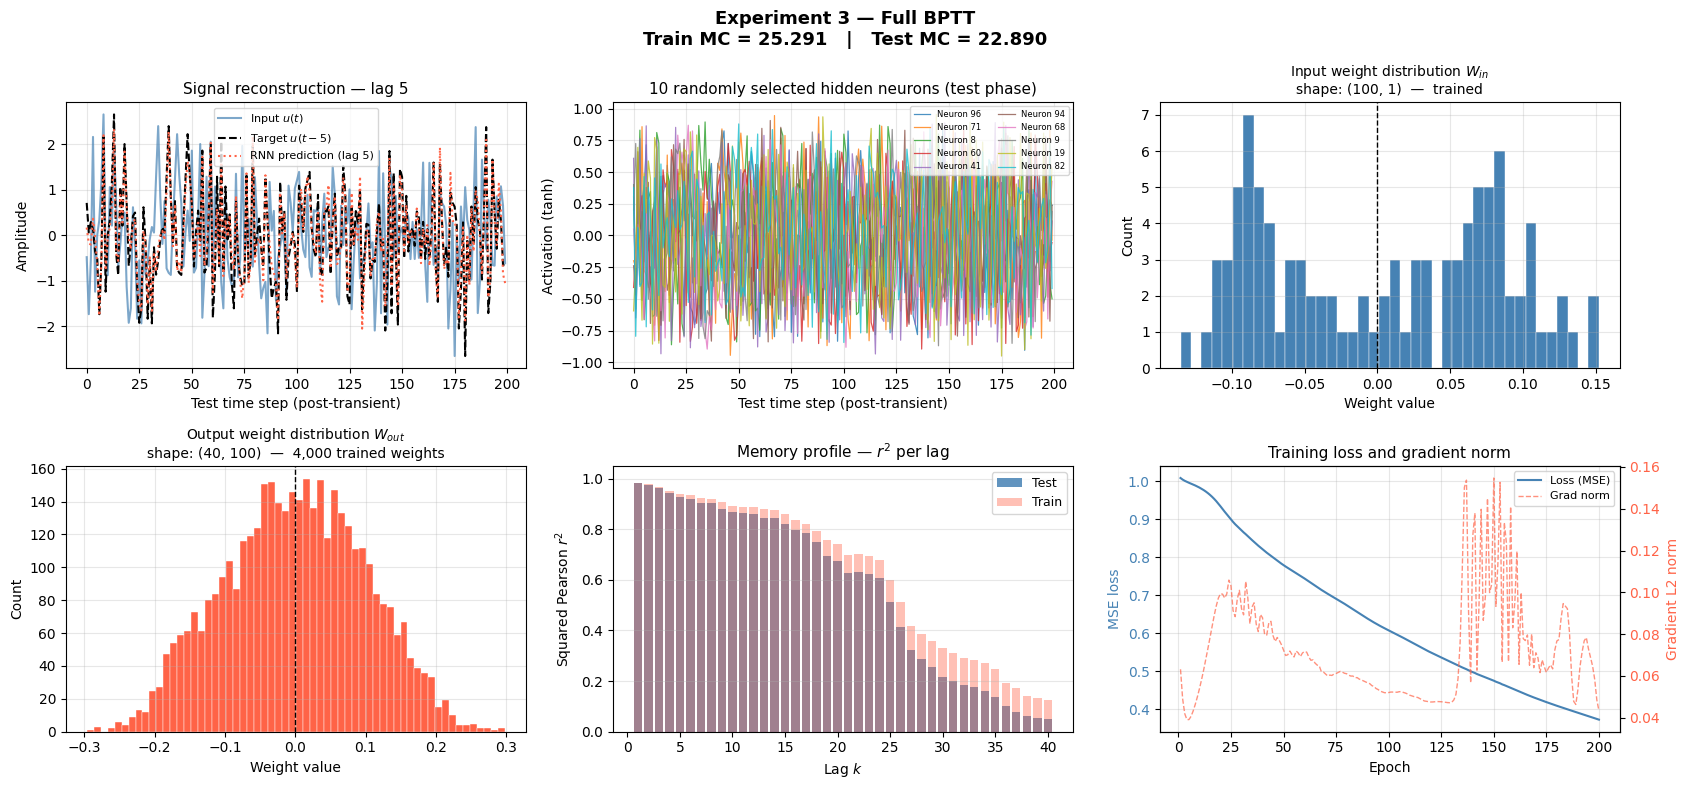

In [ ]:
mc_train_A, mc_test_A, r2_train_A, r2_test_A = evaluate_and_plot(
    model_A, 'Full BPTT', loss_history_A, grad_norm_history_A
)

---
## Part B — Chunked BPTT *(effect of gradient truncation)*

Here we demonstrate what happens when gradients are **truncated at chunk boundaries**. This is a common practical strategy to stabilize training of RNNs on long sequences.

**Important framing:** chunked BPTT is *not* a fairer comparison to the ESN, it is a *more constrained* one. Truncation imposes a hard ceiling: the gradient for lag $k$ can only flow back through `CHUNK_SIZE` steps. Since tanh gradients already decay exponentially *within* a chunk, the effective memory horizon is shorter still.

We sweep over `CHUNK_SIZES` to show this ceiling explicitly. The key question is: **at what chunk size does MC saturate?** That saturation point reveals the effective memory horizon of the trained RNN under BPTT.

Note: `CHUNK_SIZE = NUM_DELAYS` (= 40) is the principled minimum — it matches the longest lag the network needs to learn. Anything shorter is a further handicap.


Chunk size: 20  |  Grad clipping: False
Epoch   20/200  |  Loss: 0.311239  |  Grad norm: 1.0812
Epoch   40/200  |  Loss: 0.160132  |  Grad norm: 1.4888
Epoch   60/200  |  Loss: 0.122478  |  Grad norm: 1.5407
Epoch   80/200  |  Loss: 0.124242  |  Grad norm: 1.6030
Epoch  100/200  |  Loss: 0.144718  |  Grad norm: 1.7204
Epoch  120/200  |  Loss: 0.131104  |  Grad norm: 1.7247
Epoch  140/200  |  Loss: 0.111931  |  Grad norm: 1.5789
Epoch  160/200  |  Loss: 0.112570  |  Grad norm: 1.6244
Epoch  180/200  |  Loss: 0.123452  |  Grad norm: 1.7694
Epoch  200/200  |  Loss: 0.147270  |  Grad norm: 1.8571
[Chunked BPTT  (chunk=20, clip=False)]  Train MC = 34.3693   Test MC = 32.6176


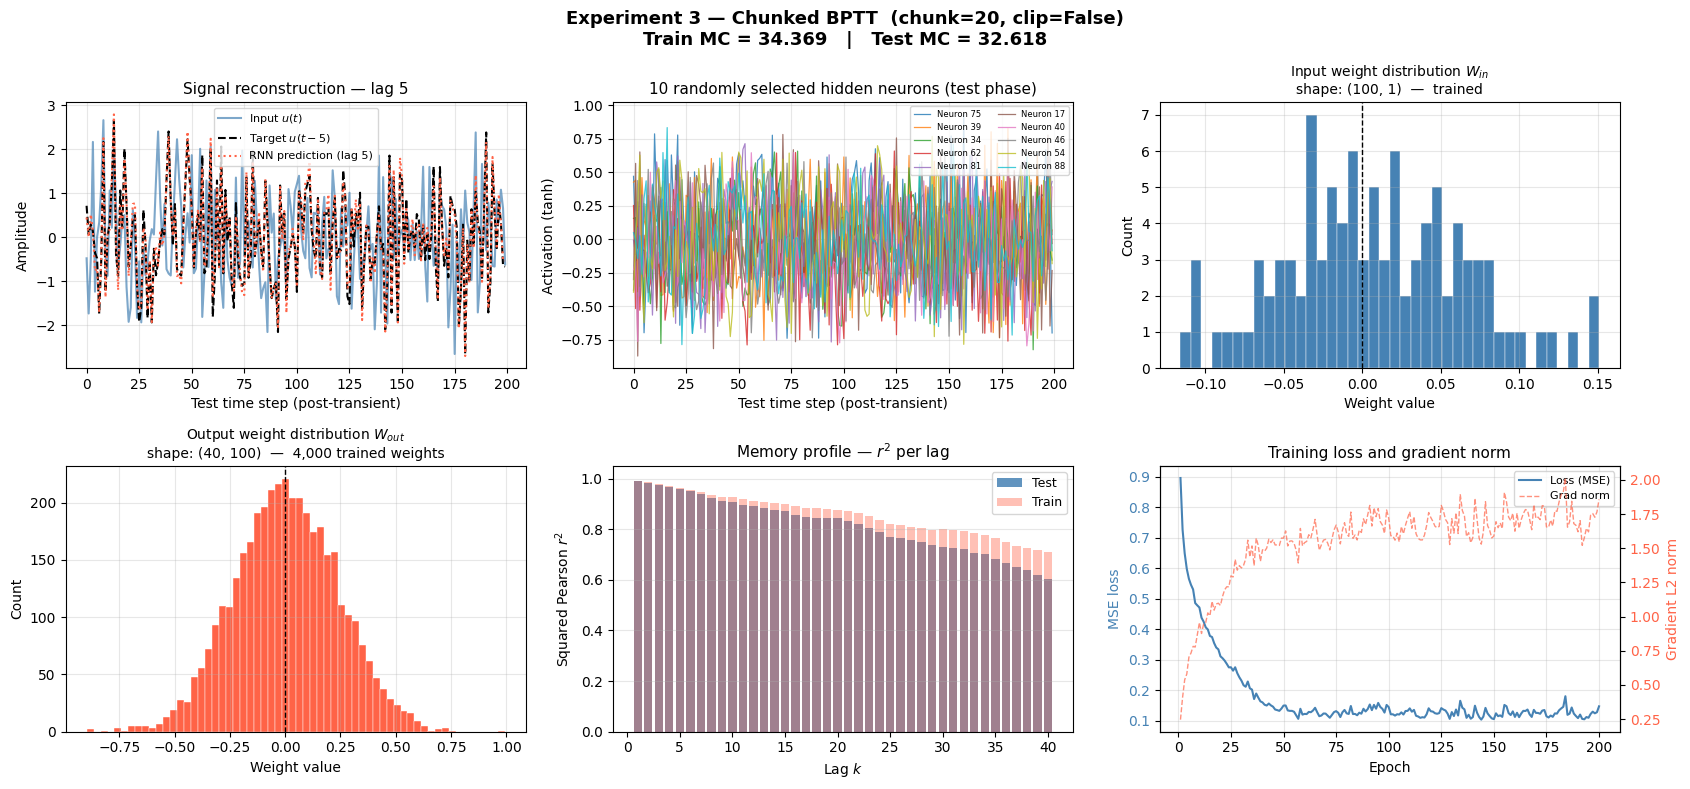


Chunk size: 40  |  Grad clipping: False
Epoch   20/200  |  Loss: 0.373314  |  Grad norm: 0.9226
Epoch   40/200  |  Loss: 0.225205  |  Grad norm: 1.3776
Epoch   60/200  |  Loss: 0.110174  |  Grad norm: 1.4907
Epoch   80/200  |  Loss: 0.102765  |  Grad norm: 1.6653
Epoch  100/200  |  Loss: 0.083257  |  Grad norm: 1.5287
Epoch  120/200  |  Loss: 0.076031  |  Grad norm: 1.4988
Epoch  140/200  |  Loss: 0.079446  |  Grad norm: 1.5841
Epoch  160/200  |  Loss: 0.069768  |  Grad norm: 1.4738
Epoch  180/200  |  Loss: 0.069270  |  Grad norm: 1.4707
Epoch  200/200  |  Loss: 0.069452  |  Grad norm: 1.5400
[Chunked BPTT  (chunk=40, clip=False)]  Train MC = 36.3853   Test MC = 35.2215


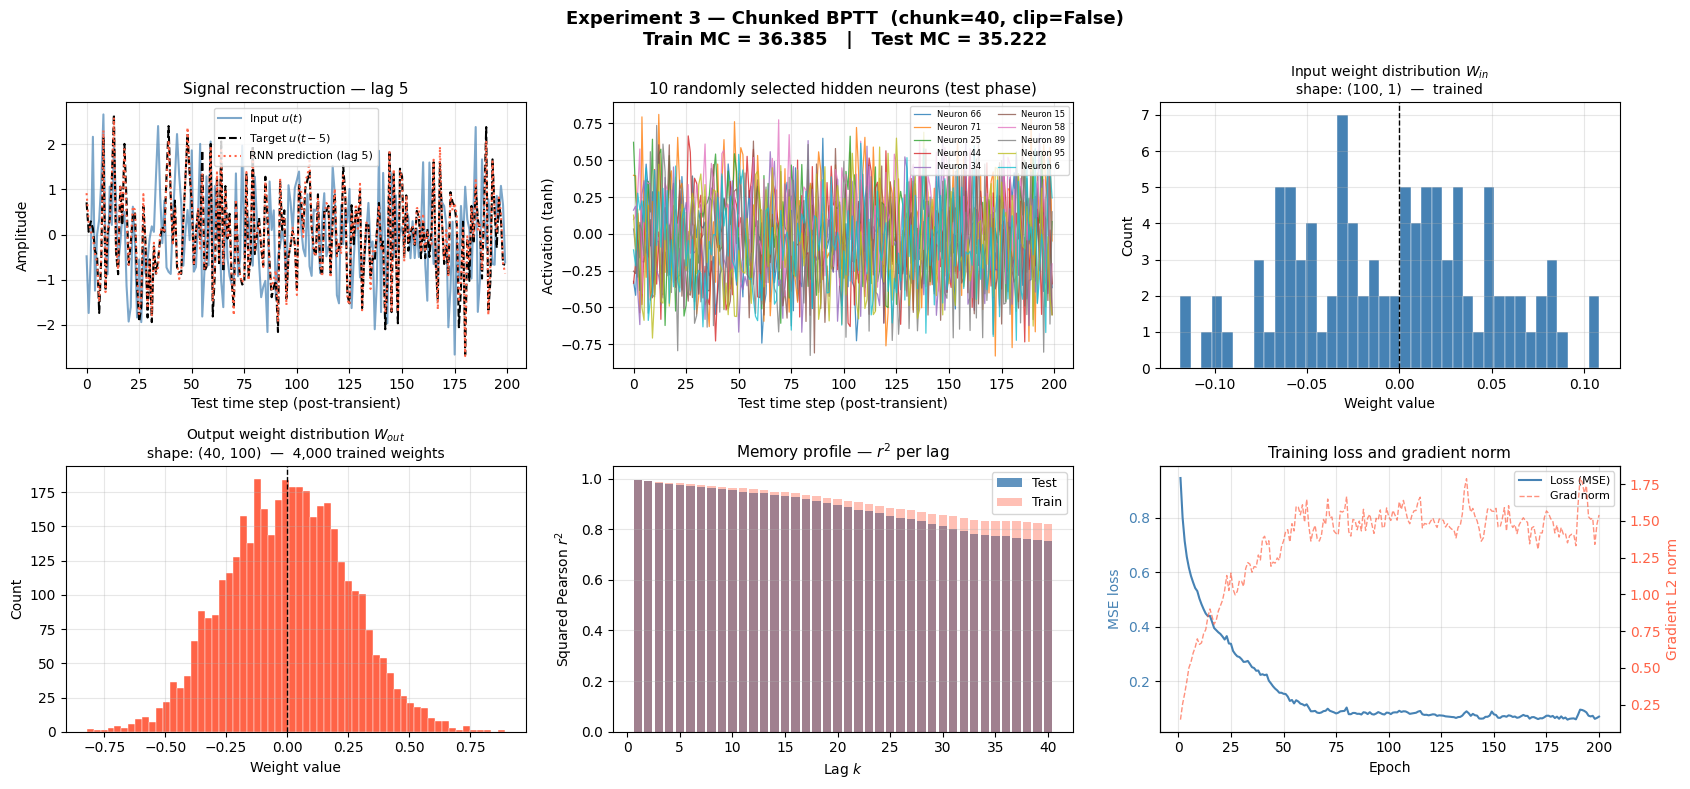


Chunk size: 100  |  Grad clipping: False
Epoch   20/200  |  Loss: 0.447577  |  Grad norm: 0.5173
Epoch   40/200  |  Loss: 0.296298  |  Grad norm: 0.7182
Epoch   60/200  |  Loss: 0.205729  |  Grad norm: 1.0931
Epoch   80/200  |  Loss: 0.097507  |  Grad norm: 1.0406
Epoch  100/200  |  Loss: 0.073502  |  Grad norm: 1.3851
Epoch  120/200  |  Loss: 0.072650  |  Grad norm: 1.4482
Epoch  140/200  |  Loss: 0.051201  |  Grad norm: 1.1159
Epoch  160/200  |  Loss: 0.038358  |  Grad norm: 1.0053
Epoch  180/200  |  Loss: 0.064282  |  Grad norm: 1.5069
Epoch  200/200  |  Loss: 0.058121  |  Grad norm: 1.4547
[Chunked BPTT  (chunk=100, clip=False)]  Train MC = 37.4936   Test MC = 36.3017


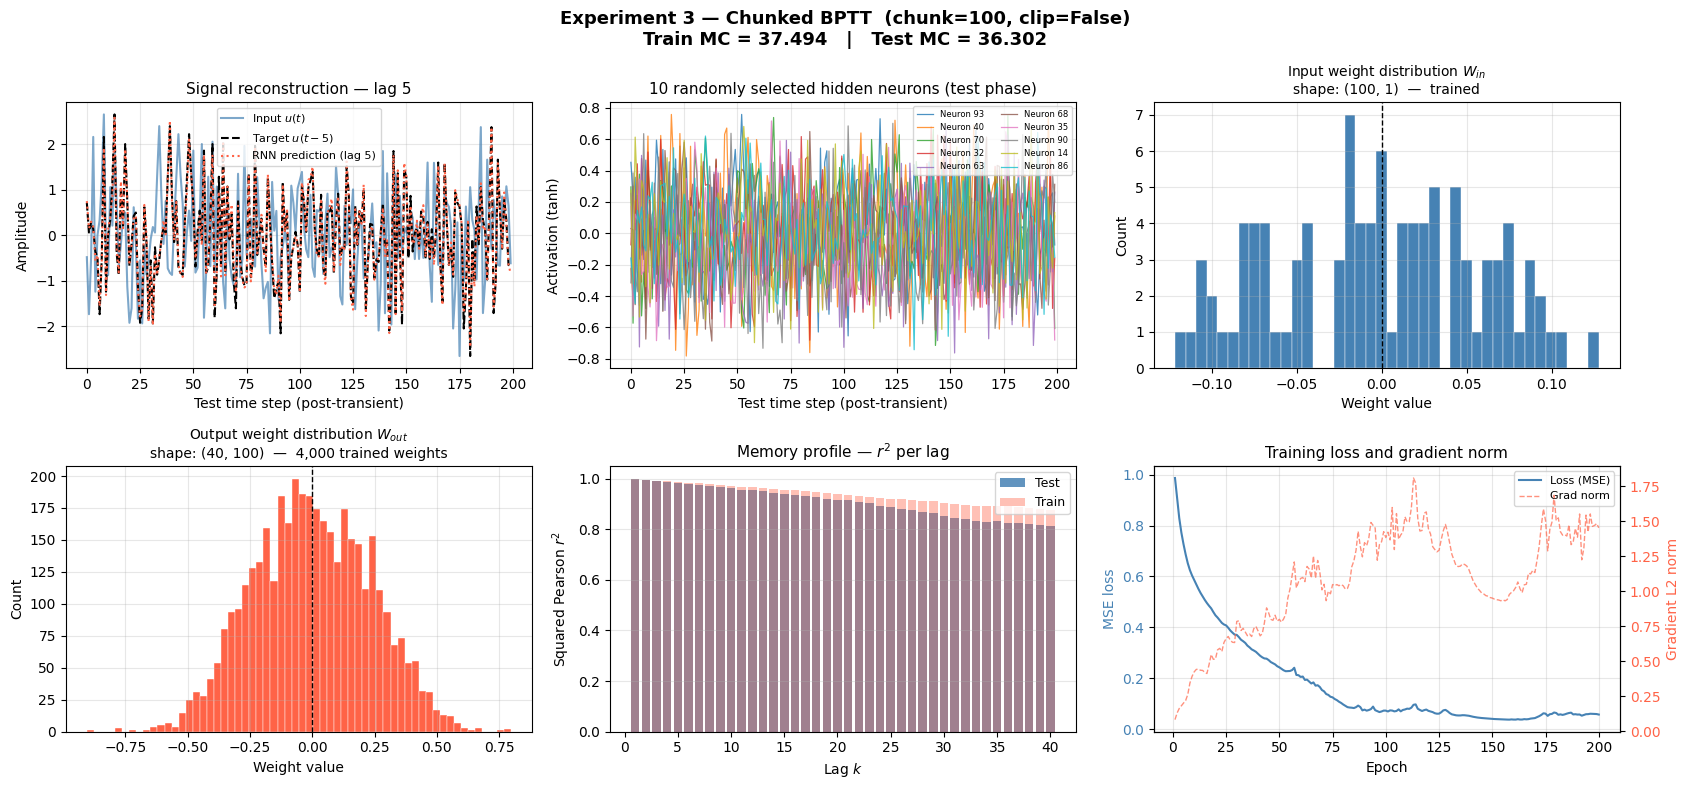

In [ ]:
chunk_results = {}   # chunk_size → (mc_test, r2_test, model, loss_hist, grad_hist)

for CHUNK_SIZE in CHUNK_SIZES:
    print(f'\n{"="*60}')
    print(f'Chunk size: {CHUNK_SIZE}  |  Grad clipping: {GRAD_CLIP}'
          + (f' (max norm={GRAD_CLIP_NORM})' if GRAD_CLIP else ''))
    print(f'{"="*60}')

    torch.manual_seed(TORCH_SEED)
    model     = VanillaRNN(N_INPUT, N_HIDDEN, N_OUTPUT, seed=TORCH_SEED).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    n_chunks = T_train // CHUNK_SIZE
    loss_history      = []
    grad_norm_history = []

    for epoch in range(N_EPOCHS):
        model.train()
        epoch_loss = 0.0
        epoch_norm = 0.0
        valid_chunks = 0
        h_n = None   # final hidden state carried across chunks, detached

        for chunk_idx in range(n_chunks):
            start = chunk_idx * CHUNK_SIZE
            end   = start + CHUNK_SIZE

            x_chunk = X_train_t[start:end]
            y_chunk = y_train_t[start:end]

            # Carry hidden state forward but detach from previous graph
            h0 = h_n.detach() if h_n is not None else None

            optimizer.zero_grad()
            out, _, h_n = model(x_chunk, h0)  # h_n: (1, 1, N_HIDDEN)

            # Skip steps that fall within the transient window
            t_local = max(0, N_TRANSIENT - start)
            if t_local >= CHUNK_SIZE:
                continue

            loss = criterion(out[t_local:], y_chunk[t_local:])
            loss.backward()

            total_norm = sum(
                p.grad.data.norm(2).item() ** 2
                for p in model.parameters() if p.grad is not None
            ) ** 0.5

            if GRAD_CLIP:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

            optimizer.step()

            epoch_loss += loss.item()
            epoch_norm += total_norm
            valid_chunks += 1

        avg_loss = epoch_loss / valid_chunks if valid_chunks else float('nan')
        avg_norm = epoch_norm / valid_chunks if valid_chunks else float('nan')
        loss_history.append(avg_loss)
        grad_norm_history.append(avg_norm)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:4d}/{N_EPOCHS}  |  '
                  f'Loss: {avg_loss:.6f}  |  Grad norm: {avg_norm:.4f}')

    mc_train, mc_test, r2_train, r2_test = evaluate_and_plot(
        model,
        f'Chunked BPTT  (chunk={CHUNK_SIZE}, clip={GRAD_CLIP})',
        loss_history, grad_norm_history
    )
    chunk_results[CHUNK_SIZE] = {
        'mc_train'  : mc_train,
        'mc_test'   : mc_test,
        'r2_test'   : r2_test,
        'loss_hist' : loss_history,
        'grad_hist' : grad_norm_history,
    }

---
## Part C — Summary comparison

Fill in the ESN reference values from Experiments 1 and 2 in the reservoir computing tutorial, then run this cell.

In [ ]:
# ── Fill in from Experiments 1 and 2
ESN_RANDOM_MC = 8.050   # mean test MC from Experiment 1
ESN_TUNED_MC  = 30.368   # mean test MC from Experiment 2

# ── Summary table
print('=' * 52)
print(f'  {"Method":<30}  {"Test MC":>8}')
print('-' * 52)
print(f'  {"ESN (random params)":<30}  '
      f'{round(ESN_RANDOM_MC, 4) if ESN_RANDOM_MC else "(fill in)":>8}')
print(f'  {"ESN (tuned params)":<30}  '
      f'{round(ESN_TUNED_MC, 4) if ESN_TUNED_MC else "(fill in)":>8}')
print(f'  {"Vanilla RNN — Full BPTT":<30}  {mc_test_A:>8.4f}')
for cs, res in chunk_results.items():
    label = f'Vanilla RNN — Chunk={cs}'
    print(f'  {label:<30}  {res["mc_test"]:>8.4f}')
print('=' * 52)

  Method                           Test MC
----------------------------------------------------
  ESN (random params)                 8.05
  ESN (tuned params)                30.368
  Vanilla RNN — Full BPTT          22.8899
  Vanilla RNN — Chunk=20           32.6176
  Vanilla RNN — Chunk=40           35.2215
  Vanilla RNN — Chunk=100          36.3017


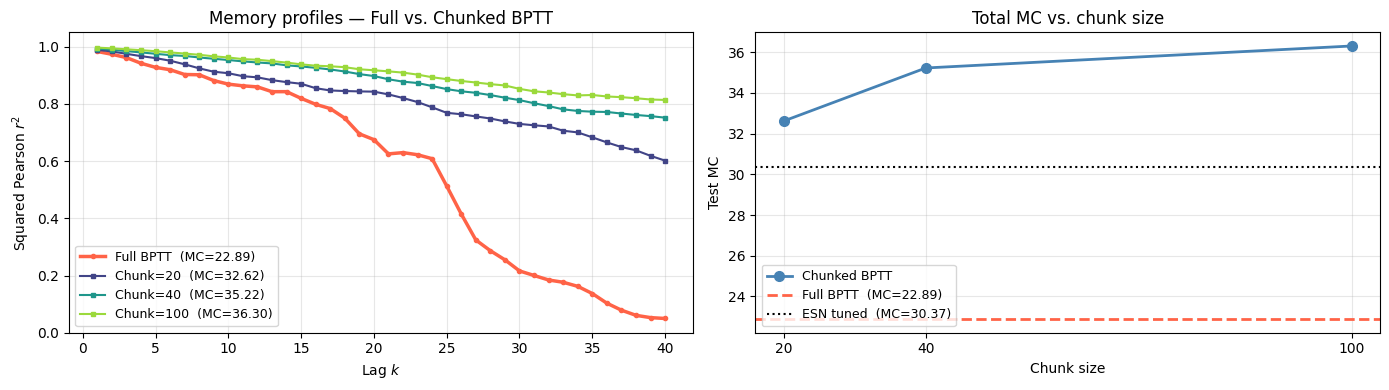

In [ ]:
# ── Memory profile overlay ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lags   = np.arange(1, NUM_DELAYS + 1)
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(CHUNK_SIZES)))

# Left: memory profiles
ax = axes[0]
ax.plot(lags, r2_test_A, color='tomato', lw=2.5, marker='o', markersize=3,
        label=f'Full BPTT  (MC={mc_test_A:.2f})')
for (cs, res), col in zip(chunk_results.items(), colors):
    ax.plot(lags, res['r2_test'], color=col, lw=1.5, marker='s', markersize=3,
            label=f'Chunk={cs}  (MC={res["mc_test"]:.2f})')
ax.set_title('Memory profiles — Full vs. Chunked BPTT', fontsize=12)
ax.set_xlabel('Lag $k$')
ax.set_ylabel('Squared Pearson $r^2$')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: total MC vs chunk size
ax = axes[1]
cs_vals = list(chunk_results.keys())
mc_vals = [chunk_results[cs]['mc_test'] for cs in cs_vals]
ax.plot(cs_vals, mc_vals, color='steelblue', lw=2, marker='o',
        markersize=7, label='Chunked BPTT')
ax.axhline(mc_test_A, color='tomato', lw=2, linestyle='--',
           label=f'Full BPTT  (MC={mc_test_A:.2f})')
if ESN_TUNED_MC:
    ax.axhline(ESN_TUNED_MC, color='black', lw=1.5, linestyle=':',
               label=f'ESN tuned  (MC={ESN_TUNED_MC:.2f})')
ax.set_title('Total MC vs. chunk size', fontsize=12)
ax.set_xlabel('Chunk size')
ax.set_ylabel('Test MC')
ax.set_xticks(cs_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_vanilla_rnn_results.png', dpi=150, bbox_inches='tight')
plt.show()